# YOLO로 틀린그림찾기

두 그림에서 다른 곳을 YOLO로 찾아 표시하고, 정답과 비교해 점수를 매긴다.
아이디어는 간단하다. YOLO로 두 그림의 물체를 전부 박스로 찾은 뒤, 박스끼리 비교한다.

여기까지 오는 과정(도안에서는 YOLO가 아무것도 못 찾음, 직접 편집한 데이터는 부자연스러움, 그래서 Gemini로 문제를 만듦)은
[report/작업기록.md](report/작업기록.md)에 정리했다. 이 노트북은 **데이터를 확인하고 탐지기를 만들어 채점하는 과정**을 순서대로 실행한다.

| 순서 | 내용 |
|---|---|
| 1 | 준비 |
| 2 | 데이터 보기 — Gemini로 만든 5문제 |
| 3 | YOLO가 이 그림을 알아볼까? |
| 4 | 박스 짝짓기 |
| 5 | 후보 자리의 내용 비교 |
| 6 | 한 문제 풀어 보기 |
| 7 | 5문제 채점 |
| 8 | 놓친 것과 한계 |

## 1. 준비

In [1]:
import json
import sys
from collections import Counter
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

plt.rcParams["font.family"] = "Malgun Gothic"      # 한글 제목
ROOT = Path.cwd()                                   # spotdiff 폴더에서 실행
sys.path.insert(0, str(ROOT / "src"))
import detect_diff as dd                            # 탐지기 코드 (src/detect_diff.py)

DS = ROOT / "dataset_ai"
answers = {k: v for k, v in json.loads((DS / "answers.json").read_text(encoding="utf-8")).items() if not k.startswith("_")}


def load(name):
    return cv2.imread(str(DS / "A" / f"{name}.png")), cv2.imread(str(DS / "B" / f"{name}.png"))


def show(img, title="", w=14):
    h = img.shape[0] / img.shape[1] * w
    plt.figure(figsize=(w, h))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title); plt.axis("off"); plt.show()


def side(A, B, gap=12):
    return cv2.hconcat([A, np.full((A.shape[0], gap, 3), 255, np.uint8), B])


print("문제:", list(answers), "/ 정답 수:", sum(len(v) for v in answers.values()))

문제: ['cafe_01', 'plaza_01', 'subway_01', 'camping_01', 'bookstore_01'] / 정답 수: 35


## 2. 데이터 보기 — Gemini로 만든 5문제

Gemini에게 장면을 설명하고 원본 A와 7군데 다른 B를 나란히 그려 달라고 해서 만든 그림이다.
제목과 설명 글자는 잘라내고 A·B 그림만 남겼다(`src/prepare_pairs.py`).
정답은 그림을 보며 정리하고, 채점할 수 있게 위치를 박스로 적었다(`dataset_ai/answers.json`).

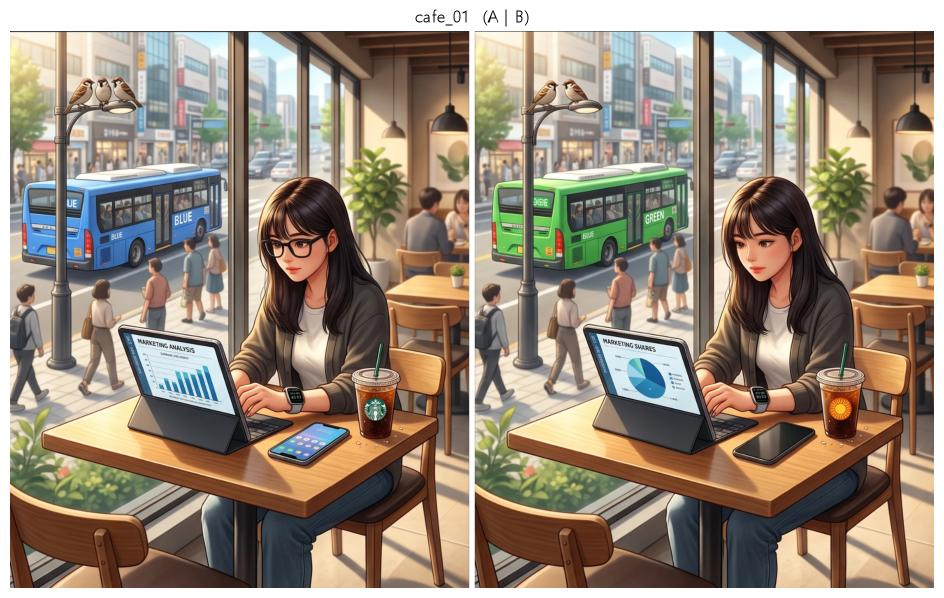

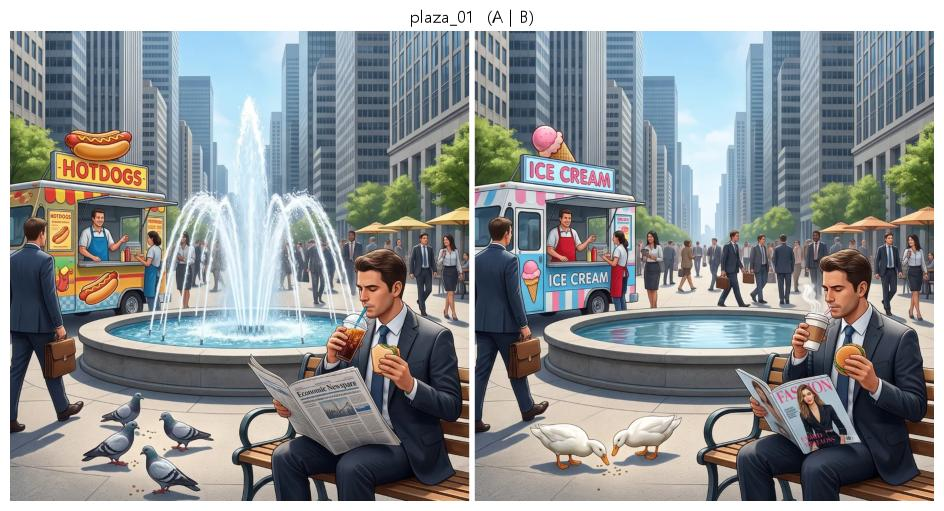

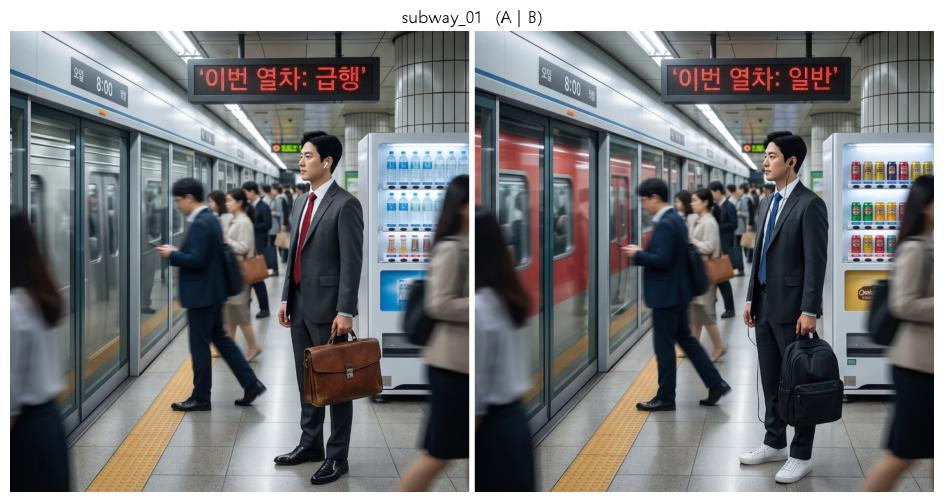

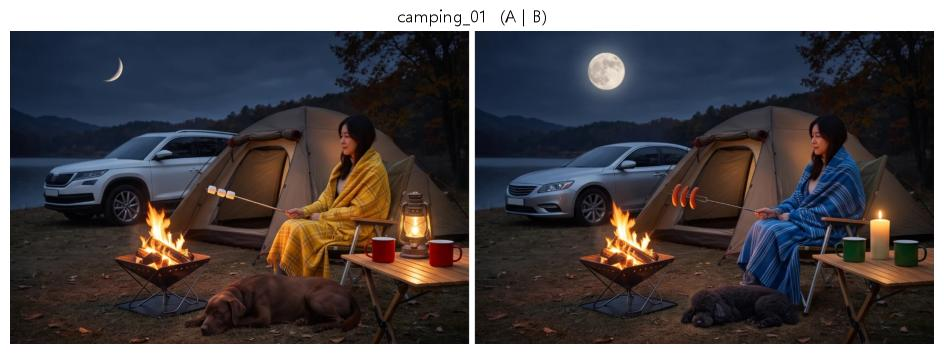

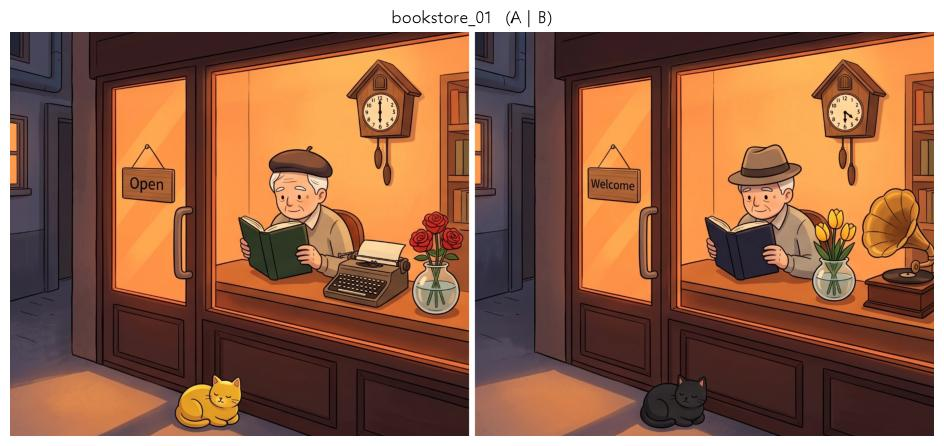

In [2]:
for name in answers:
    A, B = load(name)
    show(side(A, B), f"{name}  (A | B)", w=12)

In [3]:
# 정답 목록
rows = [(name, d["no"], d["what"]) for name, v in answers.items() for d in v]
pd.set_option("display.max_colwidth", 60)
pd.DataFrame(rows, columns=["문제", "번호", "무엇이 바뀌었나"])

,문제,번호,무엇이 바뀌었나
0,cafe_01,1,참새 3마리 → 2마리
1,cafe_01,2,파란 버스 → 초록 버스
2,cafe_01,3,안경 사라짐
3,cafe_01,4,태블릿 화면 막대그래프 → 원그래프
4,cafe_01,5,휴대폰 화면 켜짐 → 꺼짐
5,cafe_01,6,컵 로고
6,plaza_01,1,핫도그 트럭 → 아이스크림 트럭
7,plaza_01,2,앞치마 파랑 → 빨강
8,plaza_01,3,분수 물줄기 사라짐
9,plaza_01,4,비둘기 4마리 → 오리 2마리


대부분이 **같은 자리의 물체가 다른 것으로 바뀐 것**이다(핫도그 트럭 → 아이스크림 트럭, 비둘기 → 오리).
광장 그림의 8번(파라솔 색)은 Gemini가 말하지 않은 차이인데, 아래 탐지기가 찾아내서 정답에 추가했다.

## 3. YOLO가 이 그림을 알아볼까?

선 그림 도안에서는 사전학습 YOLO가 물체를 하나도 찾지 못했다. Gemini 그림은 실제 사진에 가까운 그림이라 다를 것으로 보고,
카페 그림에 작은 모델(YOLO11n)과 큰 모델(YOLO11x)을 돌려 비교했다.

In [4]:
from ultralytics import YOLO

A, B = load("cafe_01")
for weight in ["yolo11n.pt", "yolo11x.pt"]:
    m = YOLO(weight)
    for side_name, img in [("A", A), ("B", B)]:
        r = m.predict(img, conf=0.25, device=0, verbose=False)[0]
        cnt = Counter(r.names[int(c)] for c in r.boxes.cls.tolist())
        print(f"{weight:11s} {side_name}: {dict(cnt.most_common())}")

yolo11n.pt  A: {'person': 11, 'chair': 6, 'car': 3, 'cup': 2, 'cell phone': 2, 'dining table': 2, 'bus': 1, 'laptop': 1, 'potted plant': 1, 'handbag': 1}
yolo11n.pt  B: {'person': 12, 'chair': 7, 'car': 3, 'cup': 2, 'cell phone': 2, 'dining table': 2, 'laptop': 1, 'bus': 1, 'potted plant': 1}
yolo11x.pt  A: {'person': 9, 'chair': 5, 'bird': 3, 'car': 3, 'handbag': 3, 'dining table': 3, 'potted plant': 2, 'laptop': 1, 'bus': 1, 'cell phone': 1, 'cup': 1, 'backpack': 1}
yolo11x.pt  B: {'person': 11, 'chair': 5, 'handbag': 3, 'car': 3, 'potted plant': 2, 'bird': 2, 'dining table': 2, 'laptop': 1, 'bus': 1, 'cup': 1, 'cell phone': 1, 'backpack': 1}


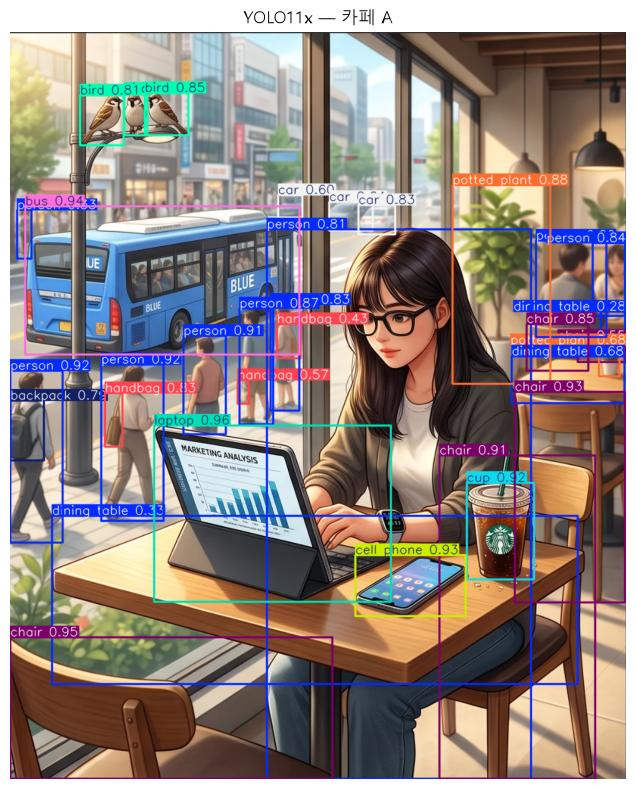

In [5]:
r = YOLO("yolo11x.pt").predict(A, conf=0.25, device=0, verbose=False)[0]
show(r.plot(line_width=2, font_size=12), "YOLO11x — 카페 A", w=8)

물체를 많이 찾는다. 큰 모델(x)은 가로등 위 작은 참새까지 찾아서 **A는 새 3마리, B는 2마리**로 차이가 박스 개수에 그대로 드러난다.
작은 모델(n)은 참새를 못 찾아서, 이후로는 YOLO11x를 쓴다.

하지만 버스 색, 태블릿 화면, 폰 화면처럼 물체는 그대로 있고 **내용만 바뀐 차이**는 A와 B에서 박스가 똑같이 나온다.
그래서 박스를 짝지은 다음, 박스 안의 내용까지 비교하기로 했다.

## 4. 박스 짝짓기

A와 B의 박스 중 위치가 많이 겹치는(IoU ≥ 0.5) 것끼리 짝을 짓는다. 겹침이 큰 쌍부터 차례로 짝을 정한다.

- 짝이 없는 박스: 한쪽에만 있는 물체 (사라짐·추가, 또는 개수가 달라짐)
- 짝이 있는데 클래스가 다름: 다른 물체로 바뀜
- 짝도 있고 클래스도 같음: 내용만 바뀌었을 수 있음

탐지 신뢰도 기준은 0.10으로 낮게 잡았다. 0.25에서는 서점 그림의 고양이와 책이 안 잡혔다. 헛탐지는 다음 단계에서 걸러진다.

In [6]:
finder = dd.Finder()                        # YOLO11x(탐지) + yolo11n-cls
da, db = finder.detect(A), finder.detect(B)
pairs, only_a, only_b = finder.pair(da, db)
print(f"A {len(da)}개, B {len(db)}개 탐지 → 짝 {len(pairs)}쌍, A에만 {len(only_a)}개, B에만 {len(only_b)}개")
print("A에만:", [da[i]["cls"] for i in only_a])
print("B에만:", [db[j]["cls"] for j in only_b])
print("클래스가 다른 짝:", [(da[i]["cls"], db[j]["cls"]) for i, j in pairs if da[i]["cls"] != db[j]["cls"]])

A 47개, B 46개 탐지 → 짝 41쌍, A에만 6개, B에만 5개
A에만: ['bird', 'bird', 'car', 'dining table', 'car', 'person']
B에만: ['bird', 'dining table', 'potted plant', 'person', 'person']
클래스가 다른 짝: []


A에만 있는 bird가 참새 한 마리 차이다. 그런데 A에만/B에만 있는 박스 중에는 사람처럼 **실제로는 양쪽에 다 있는데 YOLO가 한쪽에서만 찾은 것**도 섞여 있다.
박스만 보고 틀린 곳이라고 하면 헛탐지가 많아진다.

## 5. 후보 자리의 내용 비교

짝지은 박스, 한쪽에만 있는 박스 모두를 후보로 보고, **같은 자리를 A와 B에서 잘라 내용을 비교**한다.

- **픽셀 변화**: Gemini는 B를 새로 그리면서 선이 몇 픽셀씩 어긋나므로, 두 조각을 먼저 맞추고 살짝 흐리게 한 뒤 색이 크게 다른 픽셀의 비율을 잰다
- **색 분포**: 두 조각의 색 분포(HSV 히스토그램)가 얼마나 다른지 잰다
- (참고) **모양**: YOLO 분류 모델의 특징 벡터 거리. 처음에는 이걸로 판단하려 했지만, 거의 모든 후보가 0.0~0.2로 나와 차이를 구분하지 못했다

픽셀 변화가 0.25보다 크거나 색 분포 거리가 0.45보다 크면 틀린 곳으로 본다.

In [7]:
found, cands, _, _ = finder.find(A, B)
df = pd.DataFrame([dict(후보=c["why"], 물체=c["label"], 픽셀변화=round(c["pix"], 3), 색분포=round(c["color"], 3),
                        모양=round(c["shape"], 3), 틀린곳=c["diff"],
                        정답=[g["no"] for g in answers["cafe_01"] if dd.hits(c["box"], g)]) for c in cands])
df.sort_values("픽셀변화", ascending=False).head(12)

,후보,물체,픽셀변화,색분포,모양,틀린곳,정답
47,B에만 있음,bird,0.531,0.210,0.068,True,[1]
17,내용 비교,bus,0.524,0.618,0.019,True,[2]
41,A에만 있음,bird,0.500,0.263,0.047,True,[1]
46,A에만 있음,person,0.440,0.213,0.041,True,[2]
42,A에만 있음,bird,0.438,0.171,0.054,True,[1]
28,내용 비교,bird,0.436,0.110,0.017,True,[1]
50,B에만 있음,person,0.426,0.406,0.026,True,[2]
9,내용 비교,cell phone,0.413,0.498,0.096,True,[5]
51,B에만 있음,person,0.256,0.339,0.032,True,[2]
2,내용 비교,cup,0.134,0.244,0.019,False,[6]


버스, 휴대폰, 참새는 픽셀 변화가 0.4 이상으로 크게 나온다. 한쪽에서만 잡힌 사람 중 일부도 높게 나왔는데, 버스 바로 앞에 서 있어서
뒤에 보이는 버스 색이 바뀐 것까지 같이 잡힌 경우다(정답 2번 자리). 모양 거리는 버스(0.02)처럼 색만 바뀐 경우를 전혀 구분하지 못한다.

아래는 한쪽에서만 잡힌 후보만 모은 것이다. 참새와 버스 앞 사람을 빼면 픽셀 변화가 작아서 걸러진다.
YOLO가 한쪽에서만 놓친 물체가 이 단계에서 정리된다.

In [8]:
df[df["후보"] != "내용 비교"].sort_values("픽셀변화", ascending=False)

,후보,물체,픽셀변화,색분포,모양,틀린곳,정답
47,B에만 있음,bird,0.531,0.210,0.068,True,[1]
41,A에만 있음,bird,0.500,0.263,0.047,True,[1]
46,A에만 있음,person,0.440,0.213,0.041,True,[2]
42,A에만 있음,bird,0.438,0.171,0.054,True,[1]
50,B에만 있음,person,0.426,0.406,0.026,True,[2]
51,B에만 있음,person,0.256,0.339,0.032,True,[2]
43,A에만 있음,car,0.000,0.139,0.000,False,[]
44,A에만 있음,dining table,0.000,0.146,0.000,False,[]
45,A에만 있음,car,0.000,0.163,0.000,False,[]
48,B에만 있음,dining table,0.000,0.164,0.001,False,[]


## 6. 한 문제 풀어 보기

틀린 곳 중 같은 종류가 붙어 있으면 하나로 묶고(자판기 병 12개 → 1묶음), 겹치면 더 구체적인 작은 박스만 남긴다.
그림에서 빨간 박스는 탐지기가 찾은 곳, 초록 박스는 찾은 정답, 노란 박스는 놓친 정답이다.

cafe_01 → ['person', 'bird', 'cell phone']


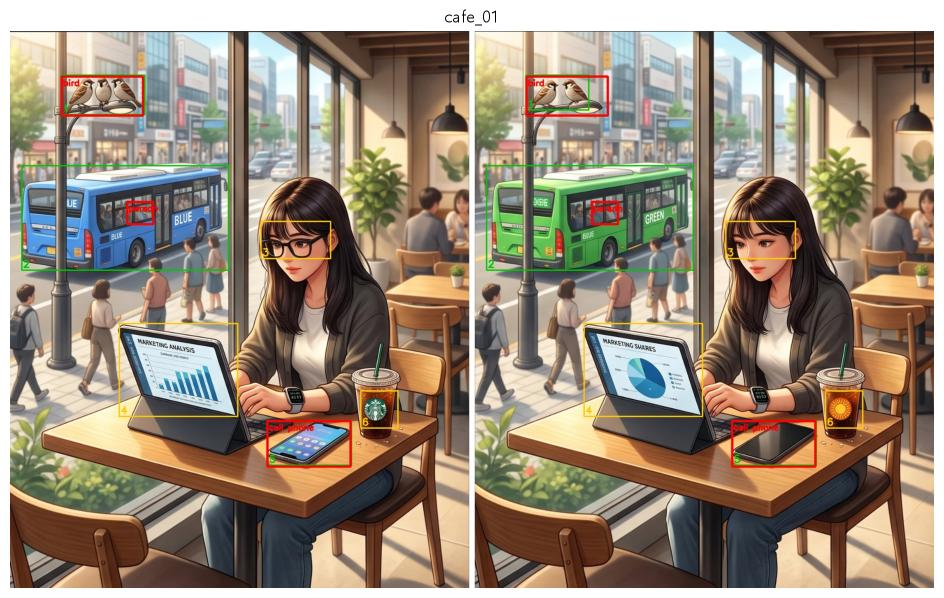

subway_01 → ['cell phone', 'tie', 'bottle', 'handbag']


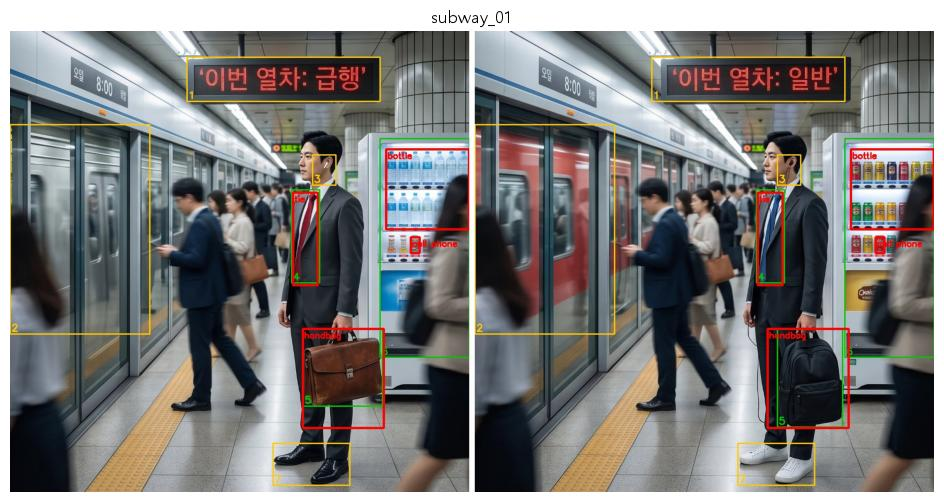

In [9]:
from pathlib import Path
out = Path("results_ai"); out.mkdir(exist_ok=True)
for name in ["cafe_01", "subway_01"]:
    A, B = load(name)
    found, *_ = finder.find(A, B)
    dd.draw(A, B, found, answers[name], out / f"{name}.jpg")
    print(name, "→", [f["label"] for f in found])
    show(cv2.imread(str(out / f"{name}.jpg")), name, w=12)

## 7. 5문제 채점

탐지 박스가 정답 박스와 겹치거나(IoU ≥ 0.1) 정답 영역 안의 일부를 가리키면 찾은 것으로 본다.
처음에는 IoU만 봤는데, 트럭 위 핫도그 장식처럼 정답의 **일부**를 정확히 가리켜도 겹치는 비율이 작아 오답이 되어서 규칙을 고쳤다.

- **재현율**: 정답 중 찾은 비율
- **정밀도**: 탐지한 것 중 정답 자리인 비율

In [10]:
rows, all_cands = [], []
for name, gts in answers.items():
    A, B = load(name)
    found, cands, *_ = finder.find(A, B)
    dd.draw(A, B, found, gts, out / f"{name}.jpg")
    all_cands += [(c["pix"], c["color"], any(dd.hits(c["box"], g) for g in gts)) for c in cands]
    rows.append(dict(문제=name, 정답=len(gts),
                     찾음=sum(any(dd.hits(f["box"], g) for f in found) for g in gts),
                     탐지=len(found),
                     맞음=sum(any(dd.hits(f["box"], g) for g in gts) for f in found),
                     놓친것=", ".join(g["what"] for g in gts if not any(dd.hits(f["box"], g) for f in found))))
score = pd.DataFrame(rows)
tot = score[["정답", "찾음", "탐지", "맞음"]].sum()
print(f"재현율 {tot['찾음'] / tot['정답']:.1%} ({tot['찾음']}/{tot['정답']}),  정밀도 {tot['맞음'] / tot['탐지']:.1%} ({tot['맞음']}/{tot['탐지']})")
score

재현율 65.7% (23/35),  정밀도 100.0% (26/26)


,문제,정답,찾음,탐지,맞음,놓친것
0,cafe_01,6,3,3,3,"안경 사라짐, 태블릿 화면 막대그래프 → 원그래프, 컵 로고"
1,plaza_01,8,8,11,11,
2,subway_01,7,3,4,4,"전광판 급행 → 일반, 은색 열차 → 빨간 열차, 무선 이어폰 → 유선 이어폰, 검은 구두 → 흰 운동화"
3,camping_01,7,5,4,4,"초승달 → 보름달, 마시멜로 → 소시지"
4,bookstore_01,7,4,4,4,"Open → Welcome 팻말, 베레모 → 중절모, 시계 바늘"


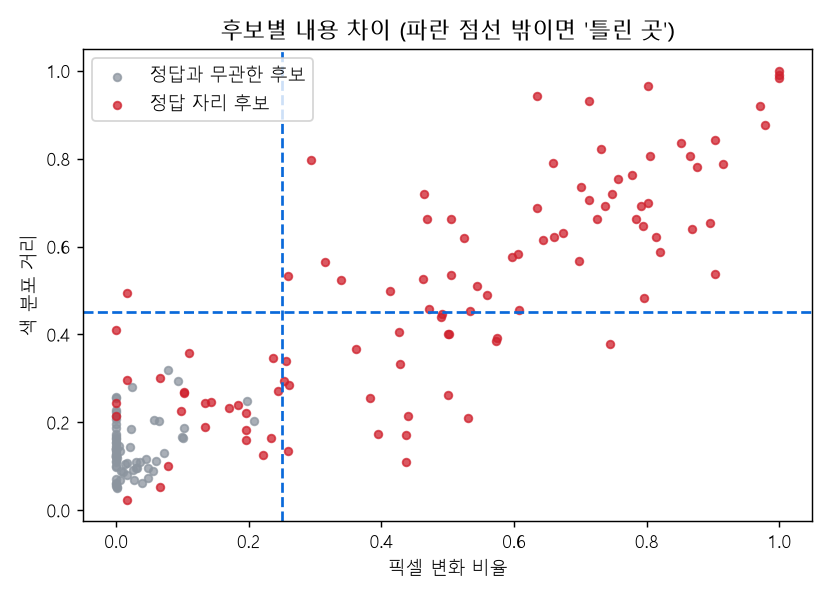

In [11]:
dd.plot(all_cands, out / "threshold.png")
display(Image(filename=str(out / "threshold.png"), width=560))

회색(정답과 무관한 후보)은 거의 다 왼쪽 아래에 모여 있고, 빨강(정답 자리 후보)은 픽셀 변화가 큰 쪽으로 퍼져 있다.
픽셀 변화 기준선(0.25)이 둘을 잘 가른다.

**시행착오에 따른 점수 변화**

| 단계 | 바꾼 것 | 재현율 | 정밀도 |
|---|---|---|---|
| 1 | 박스 비교 + 색 분포 비교 | 32.4% | 34.2% |
| 2 | 채점 규칙 수정, 탐지 신뢰도 0.25 → 0.10 | 50.0% | 95.5% |
| 3 | 픽셀 변화 비교 추가, 같은 종류 묶기 | 65.7% | 100% |

3단계에서 탐지기가 찾은 파라솔 색 차이를 정답에 추가했다(34 → 35개). 파라솔을 빼고 원래 34개로 세면 재현율 64.7%, 정밀도 96.2%다.

## 8. 놓친 것과 한계

**놓친 12개**는 두 종류다.

- **YOLO가 모르는 물체 (8개)**: 안경, 전광판, 이어폰, 구두, 달, 마시멜로, 문 팻말, 모자.
  YOLO가 배운 80가지 물체(COCO)에 없어서 박스가 안 생기고, 박스가 없으면 비교할 후보도 없다.
- **찾았지만 차이가 작게 나옴 (4개)**: 태블릿 화면, 컵 로고, 시계 바늘, 열차 색.
  물체 박스는 잡혔지만 바뀐 부분이 박스에 비해 작거나 흐려서 기준을 넘지 못했다.

**한계**

- 기준값(픽셀 변화 0.25, 색 분포 0.45)을 같은 5문제를 보며 정했다. 새 문제에서도 맞는지는 문제를 더 만들어 확인해야 한다.
- 분수처럼 정답 영역이 큰 경우, 그 안에서 바뀐 뒤쪽 사람들을 가리켜도 맞음으로 셌다. 채점이 조금 너그럽다.
- 정밀도 100%는 5문제에서 헛탐지가 없었다는 뜻이다. 문제가 늘면 떨어질 수 있다.

YOLO가 찾은 물체 안에서만 차이를 볼 수 있다는 게 이 방법의 가장 큰 한계다.
YOLO가 모르는 물체(모자, 안경, 팻말)를 찾으려면 그런 물체까지 배운 모델이 필요하다.